<a href="https://colab.research.google.com/github/manlizhixiao9-45ff/GEOG761-Labs/blob/main/761_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [55]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.5 MB/s eta 0:00:00


In [56]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-labs') #<- Remember to change this to your own project's name!

In [57]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [58]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [59]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

Mean-composite, min/max composite, or mosaic maybe?

In [60]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [61]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

2020 since ESA WorldCover 10m v100 is used.

In [62]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [63]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

Permanent water bodies.

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [64]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [65]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [66]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [67]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

ESA layer has more spatial variation across the land areas. The classified layer has only approximate three types of color on land. The reason for this might be that we only used B2 B3 B4 and B8 to train our classified map, which limits the spectral separability.

Also, below screenshots show the difference between maps.
  
The lands around beach sides and on the ocean are different on two maps.
Maybe for our trained model, it couldn’t tell the difference between deep ocean water and water around the coasts/islands. And also, the difference between lands beneath water and normal coast lands.


Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [68]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


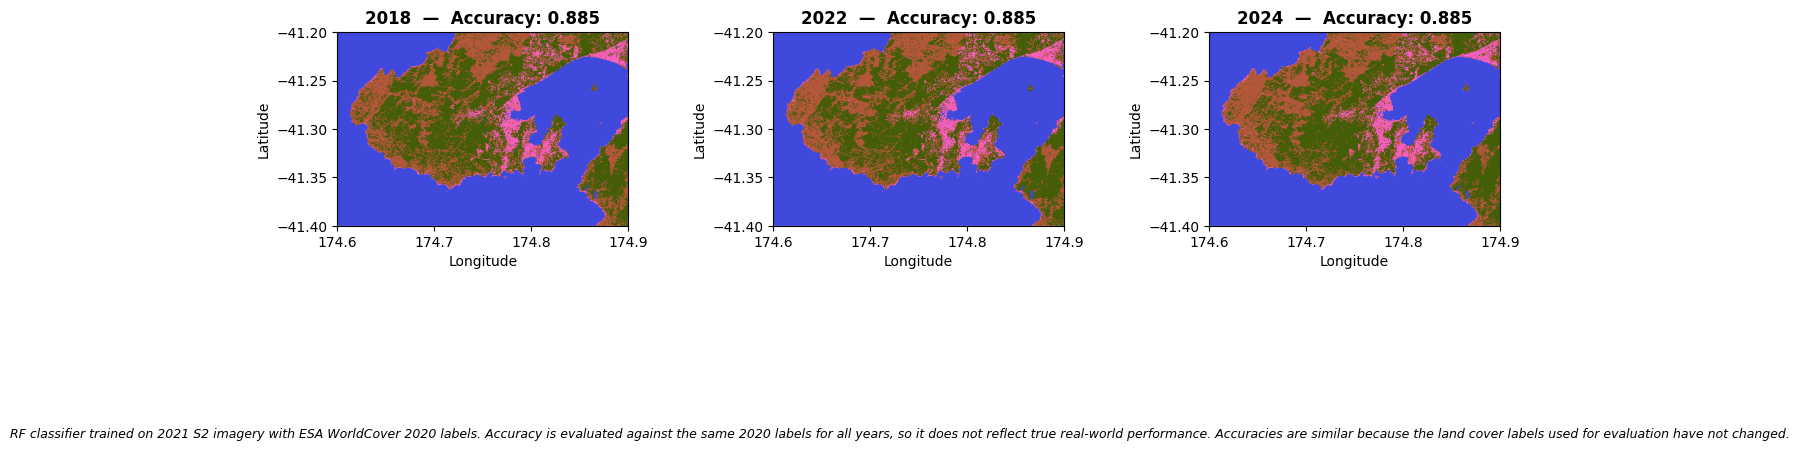

In [69]:
import matplotlib.pyplot as plt
import urllib.request
import tempfile
import matplotlib.image as mpimg

#Build cloud-masked S2 median composite for a given year
def get_s2_composite(year):
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(aoi)
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .map(mask_s2_clouds)
            .median()
            .clip(aoi))

#Train RF on a given year's S2 data, return classified image and accuracy
def train_and_classify(year):
    s2_year = get_s2_composite(year)
    training_data_year = s2_year.addBands(landcover_remapped)
    sample_year = training_data_year.select(bands + ['Map_remapped']).sample(
        region=aoi, scale=10, numPixels=5000, seed=2, geometries=True)

    #split data
    sample_year = sample_year.randomColumn('random')
    train_year  = sample_year.filter(ee.Filter.lt('random', 0.7))
    test_year   = sample_year.filter(ee.Filter.gte('random', 0.9))

    #Train RF and classify
    classifier_year = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
        features=train_year,
        classProperty='Map_remapped',
        inputProperties=bands)

    classified_year = s2_year.select(bands).classify(classifier_year)

    #Compute accuracy on test set
    y_true, y_pred = fc_to_lists(
        test_year.classify(classifier_year, 'predicted'), 'Map_remapped', 'predicted')

    report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names], output_dict=True)
    accuracy = report['accuracy']

    return classified_year, accuracy

#Run for each year
results = {}
for year in [2018, 2022, 2024]:
    classified, acc = train_and_classify(year)
    results[year] = (classified, acc)

#Get AOI bounding box for image extent
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

xmin, xmax, ymin, ymax = get_bounds_coords(aoi)

#Create figure
fig = plt.figure(figsize=(15, 6))
gs  = fig.add_gridspec(1, 3, wspace=0.5)

years = [2018, 2022, 2024]
for i in range(len(years)):
    year = years[i]
    classified, acc = results[year]
    ax = fig.add_subplot(gs[0, i])

    #Download thumbnail from GEE and display
    url = classified.randomVisualizer().getThumbURL(
        {'dimensions': 400, 'region': aoi, 'format': 'png', 'bands': ['viz-red', 'viz-green', 'viz-blue']})

    with tempfile.NamedTemporaryFile(suffix='.png') as f:
        urllib.request.urlretrieve(url, f.name)
        img = mpimg.imread(f.name)
        ax.imshow(img, extent=[xmin, xmax, ymin, ymax])

    ax.set_title(f'{year}  —  Accuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude',  fontsize=10)

fig.text(0.5, -0.02,
    'RF classifier trained on 2021 S2 imagery with ESA WorldCover 2020 labels. '
    'Accuracy is evaluated against the same 2020 labels for all years, so it does not reflect true real-world performance. '
    'Accuracies are similar because the land cover labels used for evaluation have not changed.',
    ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('Q5_figure.png', dpi=300, bbox_inches='tight')
plt.show()

# SVMs Applied to Satellite Data

In [70]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [71]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp") #<- Check file names
print(gdf.head())


Saving lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip to lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP (6).zip
           Name_2018          Name_2012          Name_2008          Name_2001  \
0  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
1     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
2  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
3     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
4  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   

           Name_1996  Class_2018  Class_2012  Class_2008  Class_2001  \
0  Indigenous Forest          69          69          69          69   
1     Sand or Gravel          10          10          10          10   
2  Indigenous Forest          69          69          69          69   
3     Sand or Gravel          10          10          10       

In [72]:
# Define AOI — Great Barrier Island (Aotea)
gbi_aoi = ee.Geometry.Rectangle([175.22, -36.37, 175.60, -36.02])

Map_gbi = geemap.Map(center=[-36.195, 175.41], zoom=10)
Map_gbi.addLayer(gbi_aoi, {'color': 'red'}, 'GBI AOI')
Map_gbi

Map(center=[-36.195, 175.41], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…

In [73]:
# Reproject to WGS84 then filter to GBI
gdf = gdf.to_crs('EPSG:4326')
gdf_gbi = gdf.cx[175.22:175.60, -36.37:-36.02].copy()

# Group LCDB 2018 classes into 6 broad categories
class_groups = {
    69: 1, 54: 1, 71: 1, 64: 1,            # Forest
    52: 2, 51: 2, 46: 2,                    # Scrub
    40: 3, 41: 3, 33: 3,                    # Grassland
    70: 4, 45: 4,                           # Wetland
    1: 5, 2: 5, 5: 5, 6: 5,                # Built-up
    10: 6, 16: 6, 21: 6, 22: 6, 20: 6, 12: 6,  # Bare/Water
}

gdf_gbi['grouped_class'] = gdf_gbi['Class_2018'].map(class_groups)
gdf_gbi = gdf_gbi.dropna(subset=['grouped_class'])
gdf_gbi['grouped_class'] = gdf_gbi['grouped_class'].astype(int)
print(gdf_gbi['grouped_class'].value_counts().sort_index())

grouped_class
1    218
2     98
3     89
4     13
5     15
6     99
Name: count, dtype: int64


In [74]:
# Convert to EE FeatureCollection
features = []
for _, row in gdf_gbi.iterrows():
    geom = ee.Geometry(row['geometry'].__geo_interface__)
    feat = ee.Feature(geom, {'landcover': int(row['grouped_class'])})
    features.append(feat)

lcdb_fc = ee.FeatureCollection(features)
print(f'EE FeatureCollection size: {lcdb_fc.size().getInfo()}')

EE FeatureCollection size: 532


In [75]:
# Build S2 composite for Austral summer 2018/19
def mask_s2_clouds_gbi(image):
    qa = image.select('QA60')
    cloudBitMask  = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

s2_gbi = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(gbi_aoi)
          .filterDate('2018-12-01', '2019-02-28')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
          .map(mask_s2_clouds_gbi)
          .median()
          .clip(gbi_aoi))

In [76]:
# Sample S2 at LCDB polygon locations, 70/30 train/test split
bands_gbi  = ['B2', 'B3', 'B4', 'B8']
gbi_labels = ['Forest', 'Scrub', 'Grassland', 'Wetland', 'Built-up', 'Bare/Water']

training_gbi = s2_gbi.addBands(
    ee.Image.constant(0).byte().rename('landcover').paint(lcdb_fc, 'landcover')
).select(bands_gbi + ['landcover']).sample(
    region=gbi_aoi, scale=10, numPixels=5000, seed=2, geometries=True)

training_gbi = training_gbi.randomColumn('random')
train_gbi = training_gbi.filter(ee.Filter.lt('random', 0.7))
test_gbi  = training_gbi.filter(ee.Filter.gte('random', 0.7))

print(f'Training samples: {train_gbi.size().getInfo()}')
print(f'Test samples    : {test_gbi.size().getInfo()}')

Training samples: 3479
Test samples    : 1521


In [83]:
# Train SVM and classify
svm_gbi = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train_gbi, classProperty='landcover', inputProperties=bands_gbi)

classified_gbi = s2_gbi.select(bands_gbi).classify(svm_gbi)

# Accuracy
y_true_gbi, y_pred_gbi = fc_to_lists(
    test_gbi.classify(svm_gbi, 'predicted'), 'landcover', 'predicted')

report_gbi = classification_report(y_true_gbi, y_pred_gbi, labels=list(range(1, 7)),
                                     target_names=gbi_labels, output_dict=True)
correct = sum(1 for i in range(len(y_true_gbi)) if y_true_gbi[i] == y_pred_gbi[i])
accuracy_gbi = correct / len(y_true_gbi)

print(classification_report(y_true_gbi, y_pred_gbi, labels=list(range(1, 7)),
                             target_names=gbi_labels))

              precision    recall  f1-score   support

      Forest       0.64      0.49      0.55       121
       Scrub       0.65      0.85      0.73       173
   Grassland       0.00      0.00      0.00        20
     Wetland       0.00      0.00      0.00         3
    Built-up       0.00      0.00      0.00         1
  Bare/Water       0.00      0.00      0.00         8

   micro avg       0.65      0.63      0.64       326
   macro avg       0.21      0.22      0.21       326
weighted avg       0.58      0.63      0.60       326



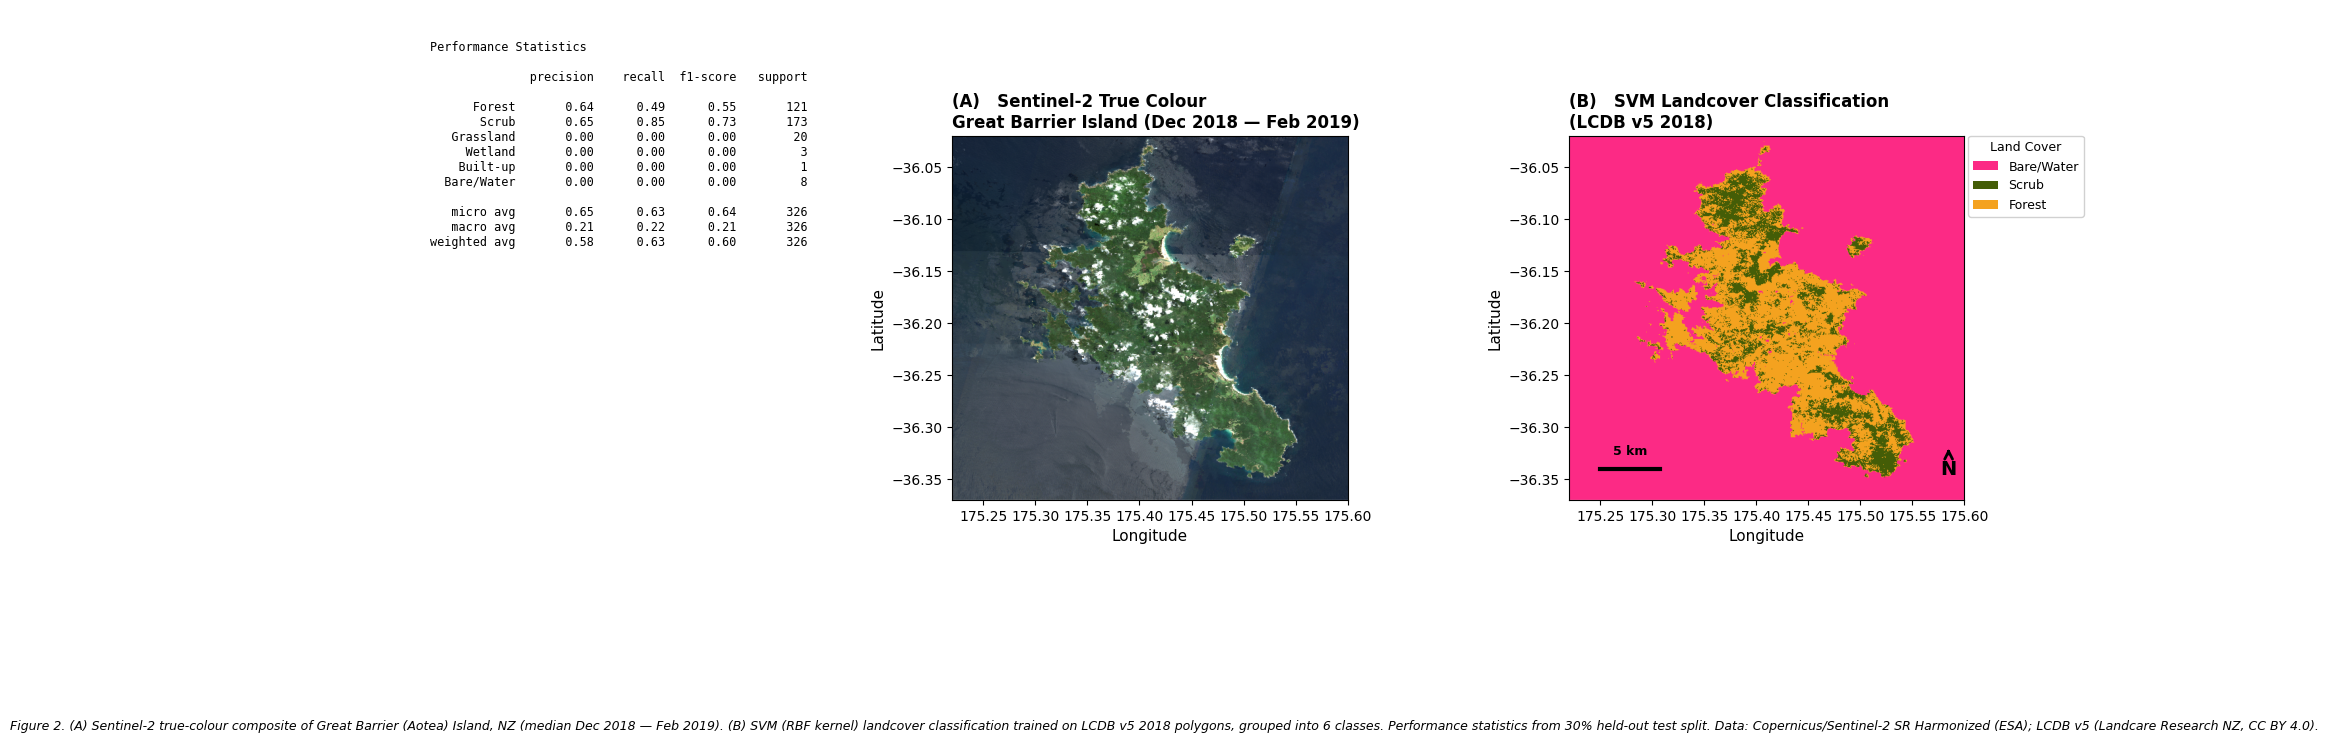

In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import urllib.request
import tempfile
import matplotlib.image as mpimg

# Extract colors assigned by randomVisualizer
sample_pixels = classified_gbi.randomVisualizer().sample(
    region=gbi_aoi, scale=100, numPixels=500, seed=42).getInfo()

class_colors = {}
for f in sample_pixels['features']:
    p = f['properties']
    cls = p['classification']
    if cls not in class_colors:
        r, g, b = int(p['viz-red']), int(p['viz-green']), int(p['viz-blue'])
        class_colors[cls] = f'#{r:02x}{g:02x}{b:02x}'

# randomVisualizer remaps original classes
class_to_label = {
    0: 'Bare/Water',
    1: 'Scrub',
    2: 'Forest',
}

xmin_g, xmax_g, ymin_g, ymax_g = get_bounds_coords(gbi_aoi)

thumb_rgb = s2_gbi.getThumbURL({
    'dimensions': 600, 'region': gbi_aoi, 'format': 'png',
    'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.18, 'gamma': 1.4})

thumb_cls = classified_gbi.randomVisualizer().getThumbURL({
    'dimensions': 600, 'region': gbi_aoi, 'format': 'png',
    'bands': ['viz-red', 'viz-green', 'viz-blue']})

fig = plt.figure(figsize=(20, 8))
gs  = fig.add_gridspec(1, 3, wspace=0.6, width_ratios=[0.8, 1, 1])

ax_stats = fig.add_subplot(gs[0, 0])
ax_rgb   = fig.add_subplot(gs[0, 1])
ax_cls   = fig.add_subplot(gs[0, 2])

# Performance statistics
report_str = classification_report(y_true_gbi, y_pred_gbi,
                                   labels=list(range(1, 7)), target_names=gbi_labels)
ax_stats.axis('off')
ax_stats.text(0.05, 0.95, 'Performance Statistics\n\n' + report_str,
              transform=ax_stats.transAxes, fontsize=8.5,
              va='top', ha='left', family='monospace')

# True colour
with tempfile.NamedTemporaryFile(suffix='.png') as f:
    urllib.request.urlretrieve(thumb_rgb, f.name)
    ax_rgb.imshow(mpimg.imread(f.name), extent=[xmin_g, xmax_g, ymin_g, ymax_g])
ax_rgb.set_title('(A)   Sentinel-2 True Colour\nGreat Barrier Island (Dec 2018 — Feb 2019)',
                 fontsize=12, fontweight='bold', loc='left')
ax_rgb.set_xlabel('Longitude', fontsize=11)
ax_rgb.set_ylabel('Latitude',  fontsize=11)

# Classified map
with tempfile.NamedTemporaryFile(suffix='.png') as f:
    urllib.request.urlretrieve(thumb_cls, f.name)
    ax_cls.imshow(mpimg.imread(f.name), extent=[xmin_g, xmax_g, ymin_g, ymax_g])
ax_cls.set_title('(B)   SVM Landcover Classification\n(LCDB v5 2018)',
                 fontsize=12, fontweight='bold', loc='left')
ax_cls.set_xlabel('Longitude', fontsize=11)
ax_cls.set_ylabel('Latitude',  fontsize=11)

# Legend — only classes that appear in the map
legend_handles = []
for cls in sorted(class_colors.keys()):
    label = class_to_label.get(cls, f'Class {cls}')
    legend_handles.append(patches.Patch(facecolor=class_colors[cls], label=label))
ax_cls.legend(handles=legend_handles, loc='upper left', fontsize=9,
              framealpha=0.9, title='Land Cover', title_fontsize=9,
              bbox_to_anchor=(1.01, 1), borderaxespad=0)

# North arrow
ax_cls.annotate('N', xy=(0.96, 0.15), xytext=(0.96, 0.07),
                xycoords='axes fraction', textcoords='axes fraction',
                ha='center', fontsize=14, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Scale bar (~5 km)
scale_lon_start = xmin_g + 0.03
scale_lon_end   = scale_lon_start + 0.057
scale_lat       = ymin_g + 0.03
ax_cls.plot([scale_lon_start, scale_lon_end], [scale_lat, scale_lat], color='black', linewidth=3)
ax_cls.text((scale_lon_start + scale_lon_end) / 2, scale_lat + 0.01,
            '5 km', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.text(0.5, -0.02,
    'Figure 2. (A) Sentinel-2 true-colour composite of Great Barrier (Aotea) Island, NZ '
    '(median Dec 2018 — Feb 2019). (B) SVM (RBF kernel) landcover classification trained on '
    'LCDB v5 2018 polygons, grouped into 6 classes. '
    'Performance statistics from 30% held-out test split. '
    'Data: Copernicus/Sentinel-2 SR Harmonized (ESA); LCDB v5 (Landcare Research NZ, CC BY 4.0).',
    ha='center', fontsize=9, style='italic')

plt.savefig('Q6_GreatBarrier_SVM.png', dpi=300, bbox_inches='tight')
plt.show()